### Before you execute the notebook please run: 
#### 01_sync_data.py to download the audio files from azure
#### 02_extract_features.py to splitting the files and for feature extraction and augmentation

# Importing

In [1]:
import sys
sys.path.append('src')
import io
import os
import pickle
import time
import warnings
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
!pip install azure-storage-blob
!pip install seaborn python-dotenv librosa scikit-learn
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
import tensorflow.keras.layers as L
from src.audio_pipeline import extract_features_from_audio_array, get_feature_names
from src.config import (
    ASSETS_DIR,
    ENCODER_PATH,
    MODEL_PATH,
    MONO,
    N_FEATURES, 
    SCALER_PATH,
    TARGET_SR,
)
from src.manifest_builder import (
    add_augmented_rows,
    assign_splits,
    build_manifest,
    save_manifest,
    validate_manifest,
)
from src.speaker_splitter import add_speaker_column, speaker_split

warnings.filterwarnings("ignore")
load_dotenv()


True

# Integration with Azure

In [2]:
import sys
sys.path.insert(0, 'src')
import io, os
import librosa
import numpy as np
import pandas as pd
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from src.config import TARGET_SR, MONO, MELD_EMOTION_MAP

load_dotenv()

CONTAINER_NAME     = "wav-files"
connection_string  = os.getenv("AZURE_STORAGE_CONNECTION_STRING")
blob_service       = BlobServiceClient.from_connection_string(connection_string)
container_client   = blob_service.get_container_client(CONTAINER_NAME)


def get_df_from_blob_dataset(prefix):
    emotions, file_paths = [], []
    for blob in container_client.list_blobs(name_starts_with=prefix):
        if blob.name.endswith(".wav"):
            filename = blob.name.split("/")[-1]
            parts    = filename.split("-")
            emotion  = parts[2].lower() if len(parts) >= 3 else "unknown"
            emotions.append(emotion)
            file_paths.append(blob.name)
    return pd.DataFrame({"Path": file_paths, "Emotions": emotions})


# ── MELD (emotion comes from a separate CSV uploaded alongside the audio) ─────
def get_meld_df_from_blob(blob_service, prefix="MELD/"):
   
    csv_blob  = blob_service.get_blob_client(container=CONTAINER_NAME,
                                             blob=f"{prefix}meld_labels.csv")
    csv_bytes = csv_blob.download_blob().readall()
    meld_df   = pd.read_csv(io.BytesIO(csv_bytes))

    # Keep only the 4 target emotions (surprise/fear/disgust already dropped
    # during upload, but filter again for safety)
    meld_df   = meld_df[meld_df["Emotion"].isin(MELD_EMOTION_MAP)].copy()
    meld_df["Emotions"] = meld_df["Emotion"].map(MELD_EMOTION_MAP)

    # Re-build blob paths  (must match the naming used in meld_upload.py)
    meld_df["Path"] = (
        prefix
        + meld_df["Speaker"].str.strip().str.replace(" ", "_")
        + "_dia" + meld_df["Dialogue_ID"].astype(str)
        + "_utt" + meld_df["Utterance_ID"].astype(str)
        + ".wav"
    )

    print(f"MELD: {len(meld_df)} utterances | emotion distribution:")
    print(meld_df["Emotions"].value_counts().to_string())
    return meld_df[["Path", "Emotions"]]


def load_audio_from_blob(blob_service, blob_path: str):
    clean_path  = blob_path.replace("\\", "/")
    blob_client = blob_service.get_blob_client(container=CONTAINER_NAME, blob=clean_path)
    audio_file  = io.BytesIO(blob_client.download_blob().readall())
    data, sr    = librosa.load(audio_file, sr=TARGET_SR, mono=MONO)
    return data.astype(np.float32), sr


ravdess_df = get_df_from_blob_dataset("RAVDESS/")
crema_df   = get_df_from_blob_dataset("CREMAD/")
tess_df    = get_df_from_blob_dataset("TESS/")
savee_df   = get_df_from_blob_dataset("SAVEE/")
asvp_df    = get_df_from_blob_dataset("ASVP-ESD/")
meld_df    = get_meld_df_from_blob(blob_service)          

data_path = pd.concat(
    [ravdess_df, crema_df, tess_df, savee_df, asvp_df, meld_df],
    axis=0
).reset_index(drop=True)

os.makedirs("data/csv", exist_ok=True)
data_path.to_csv("data/csv/data_path.csv", index=False)

print(f"\nTotal files: {len(data_path)}")
print("\nEmotion distribution:")
print(data_path["Emotions"].value_counts())


MELD: 3108 utterances | emotion distribution:
Emotions
neutral    1726
happy       565
angry       498
sad         319

Total files: 11623

Emotion distribution:
Emotions
neutral    3906
angry      2688
happy      2683
sad        2346
Name: count, dtype: int64


# EDA

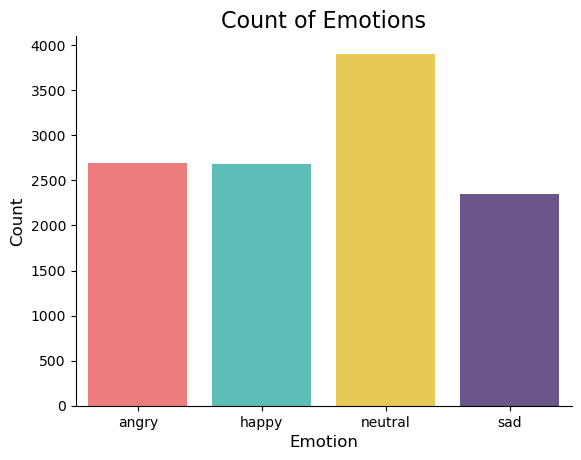

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(
    x=data_path["Emotions"],
    palette=["#FF6B6B", "#4ECDC4", "#FFD93D", "#6A4C93"]
)

plt.title('Count of Emotions', size=16)
plt.xlabel('Emotion', size=12)
plt.ylabel('Count', size=12)

sns.despine()
plt.show()

# Data Augmentation Functions

In [4]:

def noise(data, sr=None):
    noise_amp = 0.035 * np.random.uniform() * np.max(np.abs(data))
    return data + noise_amp * np.random.normal(size=data.shape[0])


def stretch(data, sr=None, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)


def shift(data, sr=None):
    shift_range = int(np.random.uniform(-5, 5) * 1000)
    return np.roll(data, shift_range)


def pitch(data, sr, n_steps=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)


AUGMENTATIONS = {
    "noise":   lambda d, sr: noise(d, sr),
    "stretch": lambda d, sr: stretch(d, sr),
    "shift":   lambda d, sr: shift(d, sr),
    "pitch":   lambda d, sr: pitch(d, sr),
}

# Data Preparation (Scaling & Encoding)

In [5]:
import sys
sys.path.insert(0, 'src')
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.utils import compute_class_weight
from src.config import DATASET_WEIGHTS

# ── Load feature CSVs ─────────────────────────────────────────────────────────
train_df2 = pd.read_csv("data/csv/train_features_ready_for_model.csv")
val_df2   = pd.read_csv("data/csv/val_features_ready_for_model.csv")
test_df2  = pd.read_csv("data/csv/test_features_ready_for_model.csv")

# ── Load spectrograms ─────────────────────────────────────────────────────────
x_train = np.stack([np.load(p) for p in train_df2["npy_path"]])
x_val   = np.stack([np.load(p) for p in val_df2["npy_path"]])
x_test  = np.stack([np.load(p) for p in test_df2["npy_path"]])

x_traincnn = x_train[..., np.newaxis]   # (N, 128, 128, 1)
x_valcnn   = x_val[...,   np.newaxis]
x_testcnn  = x_test[...,  np.newaxis]

# ── Encode labels ─────────────────────────────────────────────────────────────
encoder = OneHotEncoder(sparse_output=False)   
y_train = encoder.fit_transform(train_df2[["Labels"]])
y_val   = encoder.transform(val_df2[["Labels"]])
y_test  = encoder.transform(test_df2[["Labels"]])

# ── Option A: Dataset sample weights (upweight real-world data) ───────────────
dataset_w = train_df2["dataset_source"].map(DATASET_WEIGHTS).fillna(1.0).values

# ── Option B: Class weights (balance class frequencies) ───────────────────────
y_train_int   = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    "balanced",
    classes=np.unique(y_train_int),
    y=y_train_int,
)
class_w = class_weights[y_train_int]   # per-sample class weight

# ── Combined: multiply both, then normalise (keeps loss scale stable) ─────────
sample_weights = dataset_w * class_w
sample_weights = sample_weights / sample_weights.mean()   # mean ≈ 1.0

print(f"Dataset weight stats  — min: {dataset_w.min():.2f}  max: {dataset_w.max():.2f}")
print(f"Class weight stats    — min: {class_w.min():.2f}  max: {class_w.max():.2f}")
print(f"Combined weight stats — min: {sample_weights.min():.2f}  max: {sample_weights.max():.2f}")
print(f"\nDataset distribution in train set:")
print(train_df2["dataset_source"].value_counts())


Dataset weight stats  — min: 1.00  max: 5.00
Class weight stats    — min: 0.72  max: 1.29
Combined weight stats — min: 0.42  max: 3.78

Dataset distribution in train set:
dataset_source
CREMAD      17114
MELD        12356
ASVP-ESD     5864
TESS         5730
RAVDESS      2554
VOXONICS     2360
SAVEE        1116
Name: count, dtype: int64


# CNN Arcticeture

In [6]:
import sys
sys.path.insert(0, 'src')
import tensorflow as tf
from tensorflow.keras import layers as L, regularizers
from src.config import (
    N_MELS, FIXED_FRAMES,
    L2_REG, CNN_DROPOUT_CONV, CNN_DROPOUT_DENSE, CNN_DENSE_UNITS,LEARNING_RATE,
)

l2_reg = regularizers.l2(L2_REG)

model = tf.keras.Sequential([
    L.Conv2D(32, (3, 3), padding="same", activation="relu",
             kernel_regularizer=l2_reg,
             input_shape=(N_MELS, FIXED_FRAMES, 1)),   # ← was (128, 128, 1)
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),

    L.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Dropout(CNN_DROPOUT_CONV),                        # ← was 0.4

    L.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Dropout(CNN_DROPOUT_CONV),                        # ← was 0.4

    L.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_regularizer=l2_reg),
    L.BatchNormalization(),
    L.GlobalAveragePooling2D(),

    L.Dense(CNN_DENSE_UNITS, activation="relu"),        # ← was 64
    L.Dropout(CNN_DROPOUT_DENSE),                       # ← was 0.5
    L.Dense(y_train.shape[1], activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # ← was 0.0005
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,180 (977.27 KB)

 Trainable params: 249,476 (974.52 KB)

 Non-trainable params: 704 (2.75 KB)

# Training Callbacks

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import sys
sys.path.insert(0, 'src')
from src.config import (
    MODEL_PATH,
    CHECKPOINT_PATH, CHECKPOINT_DIR,          
    EARLY_STOPPING_PATIENCE, LR_REDUCE_PATIENCE, LR_REDUCE_FACTOR, LR_MIN,
)

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)  

callbacks = [
    ModelCheckpoint(
        str(CHECKPOINT_PATH),                  
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy", mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        patience=LR_REDUCE_PATIENCE,
        factor=LR_REDUCE_FACTOR,
        min_lr=LR_MIN, verbose=1
    ),
]


# CNN Model

Epoch 1/75
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.3992 - loss: 1.5061
Epoch 1: val_accuracy improved from None to 0.41791, saving model to C:\model_checkpoints\best_emotion_model.keras

Epoch 1: finished saving model to C:\model_checkpoints\best_emotion_model.keras
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 637s 431ms/step - accuracy: 0.4651 - loss: 1.3946 - val_accuracy: 0.4179 - val_loss: 1.3793 - learning_rate: 5.0000e-04
Epoch 2/75
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.5495 - loss: 1.2186
Epoch 2: val_accuracy improved from 0.41791 to 0.55369, saving model to C:\model_checkpoints\best_emotion_model.keras

Epoch 2: finished saving model to C:\model_checkpoints\best_emotion_model.keras
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 583s 396ms/step - accuracy: 0.5623 - loss: 1.1971 - val_accuracy: 0.5537 - val_loss: 1.1579 - learning_rate: 5.0000e-04
Epoch 3/75
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.5924 - loss: 1.1512
Epoch 3: val_accuracy did not imp

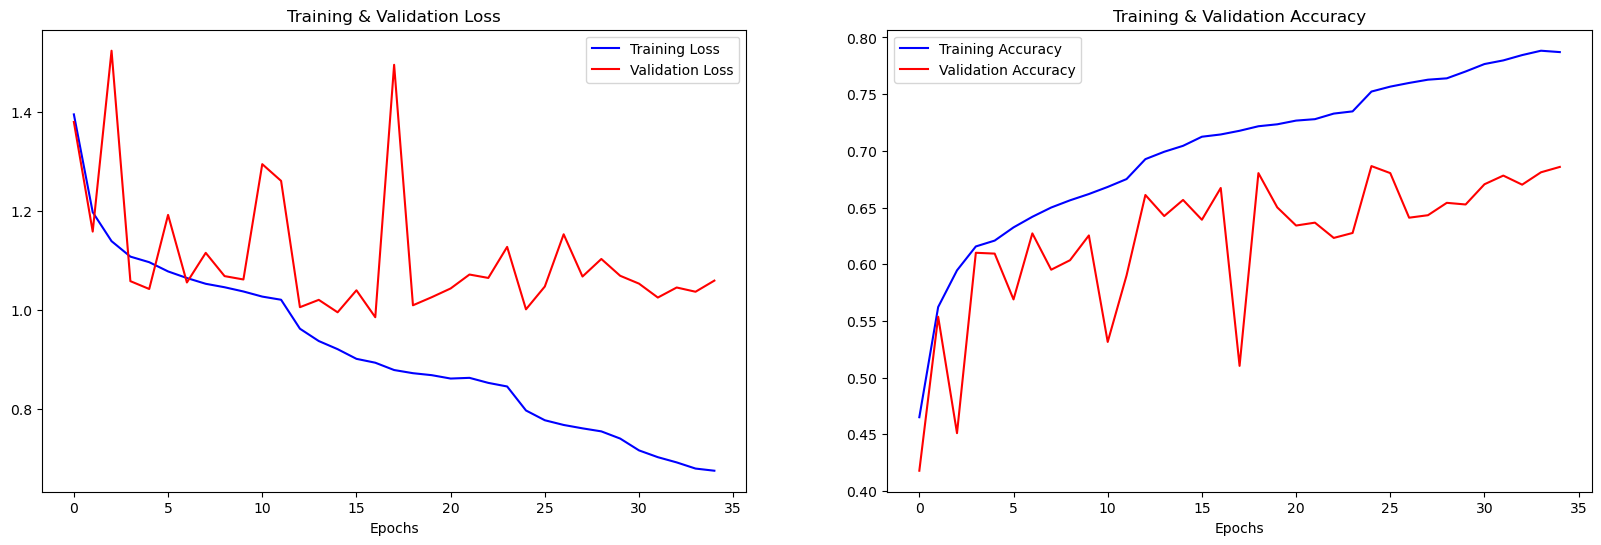

In [8]:
import matplotlib.pyplot as plt
from src.config import EPOCHS


# --- The actual training step ---
history = model.fit(
    x_traincnn, y_train,
    epochs=EPOCHS,
    validation_data=(x_valcnn, y_val),
    callbacks=callbacks,
    sample_weight=sample_weights,   # combined dataset + class weights
)


print(" Model has finished training.")


print("Plotting training history...")
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plotting Loss
ax[0].plot(epochs, history.history['loss'], label='Training Loss', color='blue')
ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

# Plotting Accuracy
ax[1].plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")

plt.show()

## Saving the encoder 

In [9]:
import pickle
import sys
sys.path.insert(0, 'src')
from src.config import ENCODER_PATH

ENCODER_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(ENCODER_PATH, "wb") as f:
    pickle.dump(encoder, f)
print(f"✓ Encoder saved to {ENCODER_PATH}")


✓ Encoder saved to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\encoder.pickle


In [10]:
# predicting on test data.
pred_test0 = model.predict(x_testcnn)
y_pred0 = encoder.inverse_transform(pred_test0)
y_test0 = encoder.inverse_transform(y_test)

# Check for random predictions
df0 = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df0['Predicted Labels'] = y_pred0.flatten()
df0['Actual Labels'] = y_test0.flatten()

df0.head(10)


87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step


,Predicted Labels,Actual Labels
0,angry,angry
1,angry,angry
2,angry,angry
3,angry,angry
4,angry,angry
5,angry,angry
6,angry,angry
7,angry,angry
8,angry,angry
9,angry,angry


# Evaluation

87/87 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step


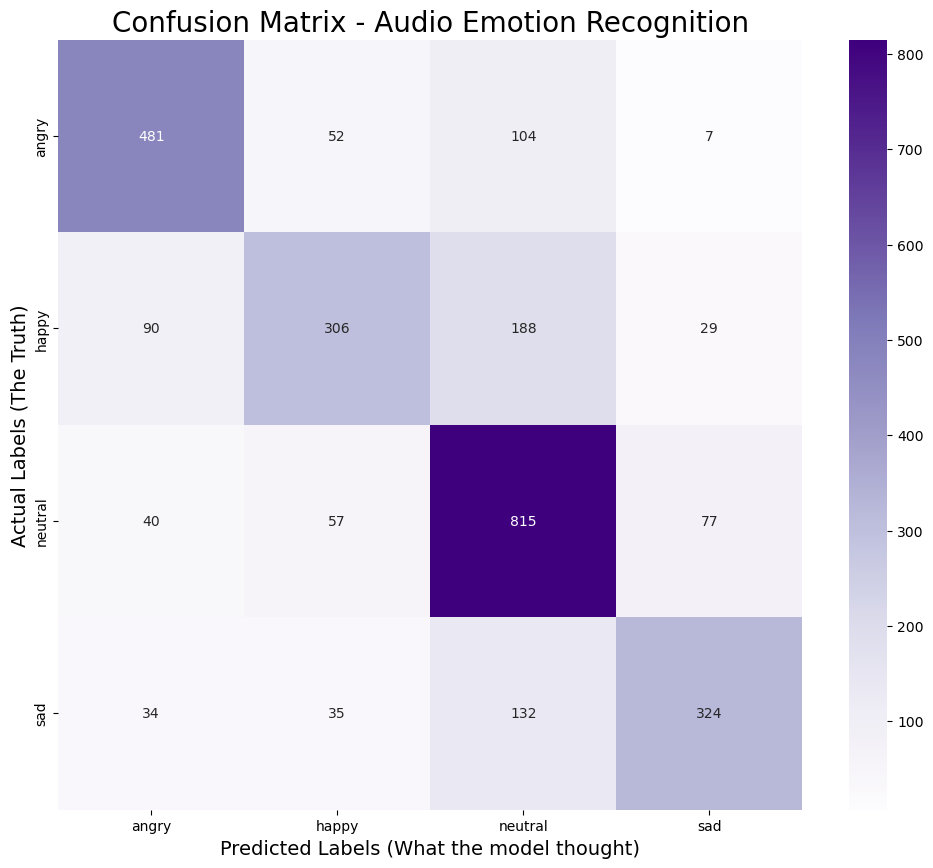


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       angry       0.75      0.75      0.75       644
       happy       0.68      0.50      0.58       613
     neutral       0.66      0.82      0.73       989
         sad       0.74      0.62      0.67       525

    accuracy                           0.70      2771
   macro avg       0.71      0.67      0.68      2771
weighted avg       0.70      0.70      0.69      2771



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


pred_test = model.predict(x_testcnn)

y_pred_labels = encoder.inverse_transform(pred_test)
y_test_labels = encoder.inverse_transform(y_test)

cm = confusion_matrix(y_test_labels, y_pred_labels)

labels = encoder.categories_[0]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Audio Emotion Recognition', size=20)
plt.xlabel('Predicted Labels (What the model thought)', size=14)
plt.ylabel('Actual Labels (The Truth)', size=14)
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_labels, y_pred_labels))

# Saving the model

In [12]:
import sys
sys.path.append('src')
import os
import pickle

# Create assets folder 
ASSETS_DIR = 'model_assets'
os.makedirs(ASSETS_DIR, exist_ok=True)

# Create Voxonics_audio directory for placing audio files to analyze
os.makedirs('Voxonics_audio', exist_ok=True)
print("Created 'Voxonics_audio/' — place your .wav files here to analyze.")

# Save model 
model_path = os.path.join(ASSETS_DIR, 'final_emotion_model.keras')
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save encoder
with open(os.path.join(ASSETS_DIR, 'encoder.pickle'), 'wb') as f:
    pickle.dump(encoder, f)

print(f"Assets saved to: {ASSETS_DIR}/")

# ===== Generate Voxonics_Predictions.py in the project root =====
script_content = '''"""
Voxonics Emotion Predictions
==============================
Predicts the emotion of a speaker from a .wav audio file.

HOW TO RUN:
-----------
Single file:
    .venv\\Scripts\\python.exe Voxonics_Predictions.py Voxonics_audio\\your_file.wav

All files in Voxonics_audio folder (PowerShell):
    Get-ChildItem .\\Voxonics_audio\\*.wav | ForEach-Object {
        .venv\\Scripts\\python.exe Voxonics_Predictions.py $_.FullName
    }
"""

import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), "src"))

import pickle
import warnings
import numpy as np
from tensorflow.keras.models import load_model

from audio_pipeline import extract_spectrogram_from_file
from config import MODEL_PATH, ENCODER_PATH

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


def load_engine():
    print("--- Loading Voxonics Engine ---")
    model = load_model(MODEL_PATH)

    with open(ENCODER_PATH, "rb") as f:
        encoder = pickle.load(f)

    return model, encoder


def predict_emotions_report(audio_path):
    model, encoder = load_engine()

    spec = extract_spectrogram_from_file(audio_path)
    features_cnn = spec[np.newaxis, ..., np.newaxis]  # (1, 128, 128, 1)

    predictions = model.predict(features_cnn, verbose=0)[0]
    emotion_labels = encoder.categories_[0]

    return {label: float(prob * 100) for label, prob in zip(emotion_labels, predictions)}


if __name__ == "__main__":
    test_audio = sys.argv[1] if len(sys.argv) > 1 else "test_voice.wav"

    if os.path.exists(test_audio):
        print(f"Analyzing: {test_audio}")
        results = predict_emotions_report(test_audio)

        print("=" * 40)
        for emotion, confidence in sorted(results.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(confidence / 5)
            print(f"{emotion.ljust(12)} | {confidence:6.2f}% {bar}")
        print("=" * 40)
    else:
        print(f"File not found: {test_audio}")
'''

with open("Voxonics_Predictions.py", "w", encoding="utf-8") as f:
    f.write(script_content)

print("Voxonics_Predictions.py created!")


Created 'Voxonics_audio/' — place your .wav files here to analyze.
Model saved to: model_assets\final_emotion_model.keras
Assets saved to: model_assets/
Voxonics_Predictions.py created!


# Unit Test

### Every time ther's a change in function in audio_pipeline.py, augmentation.py, or speaker_splitter.py
### Run the tests again to make sure nothing is broken

In [13]:
import unittest
import sys
from pathlib import Path

project_root = Path.cwd()

sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "tests"))

loader = unittest.TestLoader()
suite = unittest.TestSuite()

for test_module in [
    "test_audio_pipeline",
    "test_speaker_splitter",
    "test_augmentation",
]:
    suite.addTests(loader.loadTestsFromName(test_module))

runner = unittest.TextTestRunner(verbosity=2, stream=sys.stdout)
result = runner.run(suite)

test_crops_long_audio (test_audio_pipeline.TestCropOrPad.test_crops_long_audio) ... ok
test_exact_length_unchanged (test_audio_pipeline.TestCropOrPad.test_exact_length_unchanged) ... ok
test_invalid_crop_mode_raises (test_audio_pipeline.TestCropOrPad.test_invalid_crop_mode_raises) ... ok
test_invalid_pad_mode_raises (test_audio_pipeline.TestCropOrPad.test_invalid_pad_mode_raises) ... ok
test_output_is_float32 (test_audio_pipeline.TestCropOrPad.test_output_is_float32) ... ok
test_pads_short_audio (test_audio_pipeline.TestCropOrPad.test_pads_short_audio) ... ok
test_feature_vector_is_float32 (test_audio_pipeline.TestExtractFeatures.test_feature_vector_is_float32) ... ok
test_feature_vector_length (test_audio_pipeline.TestExtractFeatures.test_feature_vector_length) ... ok
test_feature_vector_no_inf (test_audio_pipeline.TestExtractFeatures.test_feature_vector_no_inf) ... ok
test_feature_vector_no_nan (test_audio_pipeline.TestExtractFeatures.test_feature_vector_no_nan) ... ok
test_load_from